# GRUPO 43 — Entrega 4: Random Forest con características de polaridad por oración

**Punto de partida (entrega 3):** Random Forest sobre bolsa de palabras binaria dio F1 macro ≈ 0.79. Concluimos que el problema no era la información sino **cómo se la dábamos al modelo**: miles de columnas dispersas en las que cada árbol solo puede mirar una palabra a la vez.

**Idea de esta entrega:** en lugar de darle al Random Forest miles de palabras, le damos **pocas variables densas y con significado**, construidas a partir de la bolsa de palabras:

1. Partimos cada reseña en oraciones.
2. Con conteos de palabras (BoW) del set de entrenamiento calculamos dos "puntajes" para cada oración:
   - **Polaridad** (positivo vs negativo): qué tanto se parecen sus palabras a las de reseñas positivas o negativas.
   - **Opinión** (con juicio vs neutral): qué tanto se parecen a reseñas que dan una opinión frente a las puramente descriptivas.
3. El Random Forest recibe esos puntajes **por posición** (última oración, penúltima, …) y aprende reglas como *"si la última oración no tiene opinión, mira la polaridad de la anterior"*. Ese tipo de regla no lineal es justo lo que un árbol aprende bien.

**Reglas:** representación basada solo en conteos de palabras (BoW), clasificador `RandomForestClassifier` de scikit-learn, sin redes neuronales ni *embeddings*. `eval.csv` solo se usa al final para predecir.

In [1]:
import re, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
ORDER = ["negativo", "neutral", "positivo"]
COLORS = {"negativo": "#E45756", "neutral": "#9D9D9D", "positivo": "#54A24B"}
DATA_DIR = Path("../data")
Path("models").mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
print(train_df.shape, eval_df.shape)

(12000, 3) (3000, 2)


## 1. División train / validación

Usamos la misma partición estratificada 80/20 de todas las entregas. **Gráfica de control:** la proporción de clases en entrenamiento y en validación debe ser prácticamente idéntica; si no lo fuera, la métrica de validación estaría sesgada.

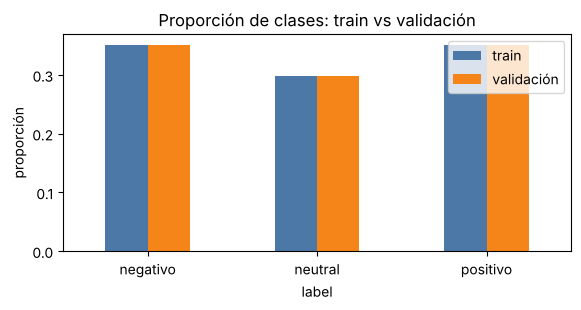

,train,validación
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


In [2]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2,
    stratify=train_df["label"], random_state=RANDOM_STATE)

prop = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "validación": y_val.value_counts(normalize=True),
}).reindex(ORDER)
ax = prop.plot(kind="bar", figsize=(6, 3.2), color=["#4C78A8", "#F58518"], rot=0)
ax.set_title("Proporción de clases: train vs validación")
ax.set_ylabel("proporción")
plt.tight_layout(); plt.show()
prop.round(3)

**Qué sale:** las proporciones coinciden (≈ 35 % / 30 % / 35 %). La estratificación funciona.

## 2. Preparación: separar en oraciones

Es la misma limpieza de las entregas anteriores (minúsculas, sin tildes, solo letras), pero ahora conservamos **todas** las oraciones de la reseña en orden.

In [3]:
def quitar_tildes(t):
    t = unicodedata.normalize("NFKD", t)
    return "".join(c for c in t if not unicodedata.combining(c))

def limpiar_texto(t):
    t = quitar_tildes(str(t).lower())
    t = re.sub(r"[^a-zñ\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def separar_oraciones(t):
    oraciones = [limpiar_texto(p) for p in re.split(r"[.!?]+", str(t))]
    oraciones = [o for o in oraciones if o]
    return oraciones if oraciones else [""]

separar_oraciones(train_df["text"].iloc[1])

['se lo compre a un familiar despues de pensarla varias semanas llego en unos cuatro dias a mi casa',
 'la verdad sea dicha el soporte tecnico me resulto incumplidor para lo que necesitaba tardaban harto en contestar',
 'al final de cuentas la nitidez de la imagen se mantuvo decente en el uso diario']

## 3. Características de polaridad por oración

Lo implementamos como un transformador de scikit-learn (`PolaridadOraciones`) para que vaya dentro del `Pipeline`.

**Cómo se calculan los puntajes (`fit`):**
- *Polaridad:* con `CountVectorizer(binary=True)` contamos en cuántas **últimas oraciones** positivas y negativas aparece cada palabra. El peso de la palabra es el log del cociente de esas frecuencias (con suavizado +1, como en Naive Bayes). Es positivo si la palabra es más típica de reseñas positivas.
- *Opinión:* lo mismo sobre el texto completo, comparando reseñas con opinión (positivas y negativas) contra neutrales.
- El puntaje de una oración es la suma de los pesos de sus palabras.

**Variables que recibe el Random Forest (`transform`)**, 15 en total:
- polaridad y opinión de las últimas 4 oraciones (de la última hacia atrás);
- polaridad de la **última oración con opinión** y de la primera;
- opinión máxima, opinión total, polaridad total, número de oraciones y número de oraciones con opinión.

**Cuidado con la fuga de información:** si calculamos los pesos con las mismas reseñas a las que luego les asignamos puntajes, esos puntajes salen "demasiado buenos" en entrenamiento: el modelo vería palabras cuyo peso se calculó con su propia etiqueta. Por eso, en `fit_transform` (entrenamiento) las variables se calculan **fuera de pliegue** (*out-of-fold*, 5 *folds*): cada reseña recibe puntajes calculados con pesos aprendidos **sin ella**. Al predecir validación o `eval.csv` se usan los pesos aprendidos con todo el entrenamiento.

In [4]:
class PolaridadOraciones(BaseEstimator, TransformerMixin):
    def __init__(self, n_posiciones=4, n_folds=5, random_state=42):
        self.n_posiciones = n_posiciones
        self.n_folds = n_folds
        self.random_state = random_state

    # --- aprender los pesos de las palabras a partir de conteos BoW ---
    @staticmethod
    def _log_ratio(vec, textos, mascara_a, mascara_b):
        X = vec.transform(textos)
        a = np.asarray(X[mascara_a].sum(0)).ravel() + 1
        b = np.asarray(X[mascara_b].sum(0)).ravel() + 1
        return np.log(a / a.sum()) - np.log(b / b.sum())

    def _aprender(self, oraciones, y):
        y = np.asarray(y)
        ultimas = [o[-1] for o in oraciones]
        completos = [" ".join(o) for o in oraciones]
        v_pol = CountVectorizer(binary=True, min_df=2).fit(ultimas)
        v_op = CountVectorizer(binary=True, min_df=2).fit(completos)
        w_pol = self._log_ratio(v_pol, ultimas, y == "positivo", y == "negativo")
        w_op = self._log_ratio(v_op, completos, y != "neutral", y == "neutral")
        return v_pol, w_pol, v_op, w_op

    # --- convertir cada reseña en sus 15 variables ---
    def _features(self, oraciones, pesos):
        v_pol, w_pol, v_op, w_op = pesos
        filas = []
        for o in oraciones:
            pol = v_pol.transform(o) @ w_pol
            op = v_op.transform(o) @ w_op
            f = []
            for k in range(1, self.n_posiciones + 1):
                f += [pol[-k], op[-k]] if len(o) >= k else [0.0, -99.0]   # -99 = "no existe esa oración"
            con_opinion = np.where(op > 0)[0]
            f += [pol[con_opinion[-1]] if len(con_opinion) else 0.0,
                  pol[con_opinion[0]] if len(con_opinion) else 0.0,
                  op.max(), op.sum(), pol.sum(), len(o), len(con_opinion)]
            filas.append(f)
        return np.array(filas)

    def nombres(self):
        n = []
        for k in range(1, self.n_posiciones + 1):
            n += [f"pol_ult-{k-1}", f"op_ult-{k-1}"]
        return n + ["pol_ult_opinion", "pol_prim_opinion", "op_max", "op_total", "pol_total", "n_oraciones", "n_con_opinion"]

    def fit(self, X, y):
        self.pesos_ = self._aprender([separar_oraciones(t) for t in X], y)
        return self

    def transform(self, X):
        return self._features([separar_oraciones(t) for t in X], self.pesos_)

    def fit_transform(self, X, y):
        oraciones = [separar_oraciones(t) for t in X]
        y = np.asarray(y)
        F = np.zeros((len(oraciones), 2 * self.n_posiciones + 7))
        skf = StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state)
        for idx_fit, idx_out in skf.split(oraciones, y):
            pesos = self._aprender([oraciones[i] for i in idx_fit], y[idx_fit])
            F[idx_out] = self._features([oraciones[i] for i in idx_out], pesos)
        self.pesos_ = self._aprender(oraciones, y)   # pesos finales para transform()
        return F

### Gráfica de control: ¿las variables separan las clases y no hay fuga?

Comparamos la variable más importante, la **polaridad de la última oración con opinión**, en entrenamiento (calculada *out-of-fold*) y en validación. Si la preparación está bien:
- en ambos paneles positivo y negativo deben quedar separados y neutral concentrado cerca de 0;
- **las dos distribuciones deben verse parecidas.** Si entrenamiento estuviera mucho más separado que validación, sería señal de fuga de información.

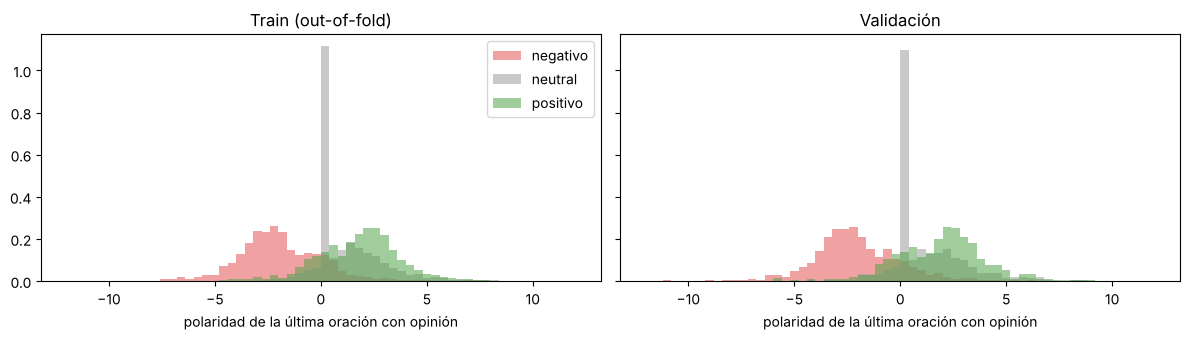

In [5]:
pol = PolaridadOraciones(random_state=RANDOM_STATE)
F_train = pol.fit_transform(X_train, y_train)
F_val = pol.transform(X_val)
col = pol.nombres().index("pol_ult_opinion")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, F, y, titulo in [(axes[0], F_train, y_train, "Train (out-of-fold)"), (axes[1], F_val, y_val, "Validación")]:
    for c in ORDER:
        ax.hist(F[np.asarray(y) == c, col], bins=60, range=(-12, 12), alpha=0.55, density=True, label=c, color=COLORS[c])
    ax.set_title(titulo); ax.set_xlabel("polaridad de la última oración con opinión")
axes[0].legend(); plt.tight_layout(); plt.show()

**Qué sale:** positivo (valores > 0) y negativo (< 0) quedan claramente separados, y las distribuciones de train y validación son muy parecidas, así que no hay fuga. Las reseñas neutrales se acumulan en 0 porque casi nunca tienen una oración con opinión.

## 4. Modelo: Random Forest y ajuste de `min_samples_leaf`

Armamos el `Pipeline` (variables → Random Forest) y probamos varios valores de `min_samples_leaf`, el mínimo de reseñas por hoja. Valores bajos permiten árboles más complejos y con más riesgo de sobreajuste; valores altos dan árboles más simples.

**Gráfica de control:** F1 en entrenamiento vs validación para cada valor. Así vemos si el modelo sobreajusta o subajusta.

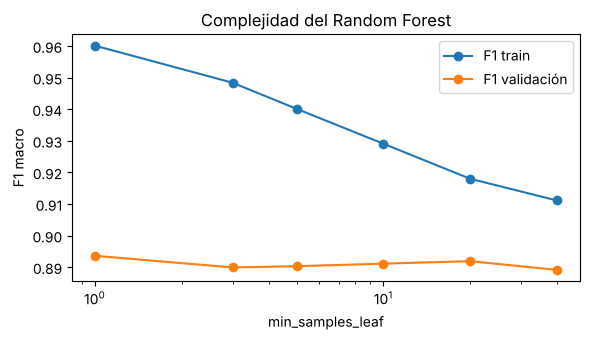

,min_samples_leaf,F1 train,F1 validación
0,1,0.9601,0.8936
1,3,0.9484,0.8899
2,5,0.9401,0.8903
3,10,0.9291,0.8911
4,20,0.9180,0.8919
5,40,0.9111,0.8891


In [6]:
def crear_modelo(leaf):
    return Pipeline([
        ("polaridad", PolaridadOraciones(random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=500, min_samples_leaf=leaf, n_jobs=-1, random_state=RANDOM_STATE)),
    ])

filas = []
for leaf in [1, 3, 5, 10, 20, 40]:
    m = crear_modelo(leaf).fit(X_train, y_train)
    filas.append({"min_samples_leaf": leaf,
                  "F1 train": f1_score(y_train, m.predict(X_train), average="macro"),
                  "F1 validación": f1_score(y_val, m.predict(X_val), average="macro")})
res = pd.DataFrame(filas)

ax = res.plot(x="min_samples_leaf", y=["F1 train", "F1 validación"], marker="o", figsize=(6, 3.5), logx=True)
ax.set_title("Complejidad del Random Forest"); ax.set_ylabel("F1 macro")
plt.tight_layout(); plt.show()
res.round(4)

**Qué sale:** el F1 de validación es estable, cerca de 0.89, en casi todo el rango, y solo cae un poco con hojas muy grandes. El F1 de entrenamiento se calcula con pesos aprendidos con todo el set, así que es optimista. Lo importante es que la brecha entre ambas curvas se cierra al aumentar `min_samples_leaf`. Escogemos el valor con mejor F1 de validación.

## 5. Evaluación en validación

min_samples_leaf = 1
Accuracy: 0.8883 | F1 macro: 0.8936

              precision    recall  f1-score   support

    negativo     0.8493    0.8422    0.8457       843
     neutral     0.9930    0.9888    0.9909       715
    positivo     0.8392    0.8492    0.8442       842

    accuracy                         0.8883      2400
   macro avg     0.8938    0.8934    0.8936      2400
weighted avg     0.8886    0.8883    0.8884      2400



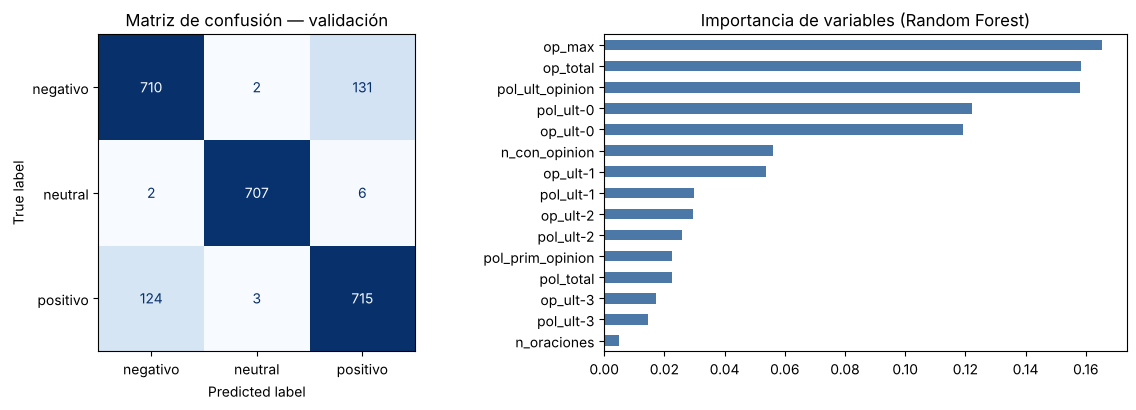

In [7]:
mejor_leaf = int(res.loc[res["F1 validación"].idxmax(), "min_samples_leaf"])
modelo = crear_modelo(mejor_leaf).fit(X_train, y_train)
pred = modelo.predict(X_val)

print(f"min_samples_leaf = {mejor_leaf}")
print(f"Accuracy: {accuracy_score(y_val, pred):.4f} | F1 macro: {f1_score(y_val, pred, average='macro'):.4f}\n")
print(classification_report(y_val, pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ConfusionMatrixDisplay.from_predictions(y_val, pred, labels=ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión — validación")

imp = pd.Series(modelo.named_steps["rf"].feature_importances_,
                index=modelo.named_steps["polaridad"].nombres()).sort_values()
imp.plot(kind="barh", ax=axes[1], color="#4C78A8")
axes[1].set_title("Importancia de variables (Random Forest)")
plt.tight_layout(); plt.show()

**Qué sale:**
- **Matriz de confusión:** `neutral` casi no se confunde. Los errores restantes son entre `positivo` y `negativo`, en reseñas mixtas.
- **Importancia de variables:** las primeras son las de **opinión** (`op_max`, `op_total`), que separan `neutral` del resto. Les siguen la polaridad de la **última oración con opinión** y la de la **última oración**, que separan `positivo` de `negativo`. Las variables de la primera oración y de posiciones más atrás casi no se usan. Esto confirma que el modelo aprende la estructura que esperábamos (la conclusión de la reseña decide), no un artefacto.

## 6. Modelo final y submission

Reentrenamos con todo `train.csv` (los pesos de palabras se recalculan con el 100 % de los datos) y predecimos `eval.csv`. El modelo se guarda comprimido para que pese poco.

Para cargar el `.joblib` en otro entorno, primero hay que definir `quitar_tildes`, `limpiar_texto`, `separar_oraciones` y la clase `PolaridadOraciones` (celdas de las secciones 2 y 3).

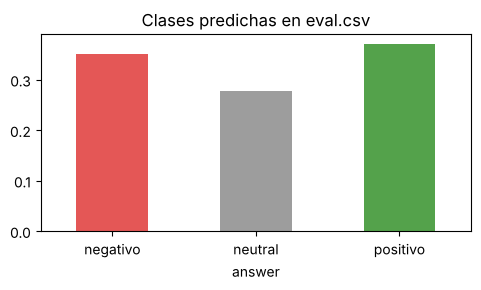

In [8]:
modelo_final = crear_modelo(mejor_leaf).fit(train_df["text"], train_df["label"])
submission = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})
assert list(submission.columns) == list(sample_sub.columns) and len(submission) == len(sample_sub)
submission.to_csv("submission-G43-4.csv", index=False)

joblib.dump(modelo_final, "models/modelo_entrega4_rf_polaridad.joblib", compress=3)
assert (joblib.load("models/modelo_entrega4_rf_polaridad.joblib").predict(eval_df["text"]) == submission["answer"]).all()

ax = submission["answer"].value_counts(normalize=True).reindex(ORDER).plot(
    kind="bar", rot=0, figsize=(5, 3), color=[COLORS[c] for c in ORDER])
ax.set_title("Clases predichas en eval.csv"); plt.tight_layout(); plt.show()

**Qué sale:** la distribución predicha en `eval.csv` es parecida a la de entrenamiento (≈ 35/30/35), así que el modelo no colapsa hacia una clase.

## Resumen

- **Cambio clave frente a la entrega 3:** pasamos de miles de columnas BoW dispersas a **15 variables de polaridad y opinión por posición de oración**, construidas con conteos BoW. Es una variable por idea, que es lo que mejor aprovecha un Random Forest.
- **Resultado:** F1 macro ≈ 0.89 en validación con Random Forest (entrega 3: ≈ 0.79).
- **Riesgo controlado:** las variables de entrenamiento se calculan *out-of-fold* para evitar fuga; la gráfica de la sección 3 lo verifica.